In [ ]:
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
GPU available: False


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [ ]:
device = torch.device(
"cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


In [ ]:

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(
root="./data",
train=True,
download=True,
transform=transform)

test_dataset = datasets.MNIST(
root="./data",
train=False,
download=True,
transform=transform)



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.46MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.88MB/s]


In [ ]:
train_loader = DataLoader(
train_dataset,
batch_size=128,
shuffle=True)

test_loader = DataLoader(
test_dataset,
batch_size=128,
shuffle=False)

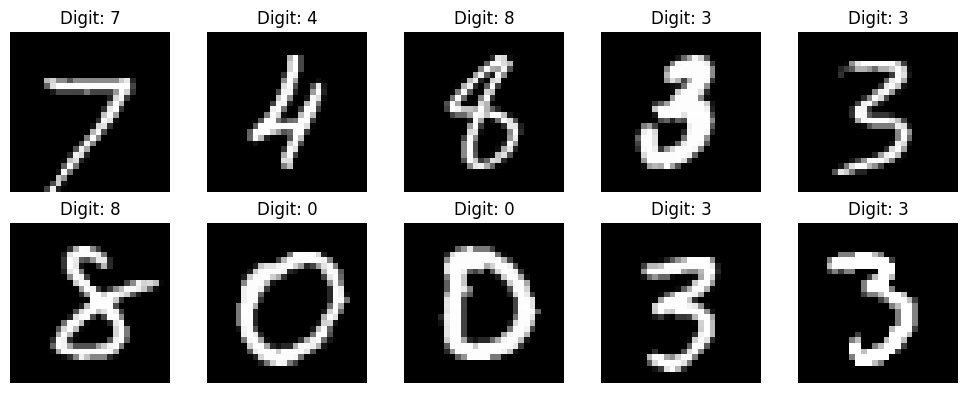

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(784, 400)

        # Latent space
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar


latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)

print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)


In [ ]:
latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)
print(model)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)


In [ ]:
def vae_loss(reconstruction, x, mu, logvar):
    reconstruction_loss = nn.functional.binary_cross_entropy(
        reconstruction,
        x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_loss


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.view(-1, 784).to(device)

        optimizer.zero_grad()

        reconstruction, mu, logvar = model(images)

        loss = vae_loss(
            reconstruction,
            images,
            mu,
            logvar
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {average_loss:.2f}"
    )

Epoch [1/10], Loss: 21175.47
Epoch [2/10], Loss: 15507.10
Epoch [3/10], Loss: 14612.02
Epoch [4/10], Loss: 14247.07
Epoch [5/10], Loss: 14030.97
Epoch [6/10], Loss: 13892.26
Epoch [7/10], Loss: 13782.93
Epoch [8/10], Loss: 13706.98
Epoch [9/10], Loss: 13636.20
Epoch [10/10], Loss: 13583.84


In [ ]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    flat_images = images.view(-1, 784)
    reconstruction, mu, logvar = model(flat_images)

reconstruction = reconstruction.view(-1, 1, 28, 28)

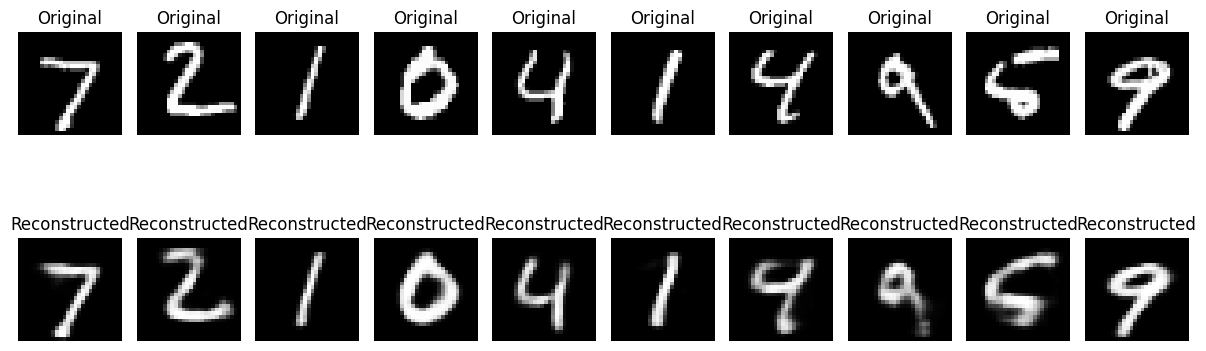

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstruction[i].cpu().squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()